In [1]:
# Mount Google Drive to access the dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Dataset Description

The dataset consists of chest X-ray images categorised into two classes:

• NORMAL  
• PNEUMONIA  

The dataset is divided into training, validation and testing sets.  
This structure helps prevent data leakage and enables reliable model evaluation.

In [2]:
# Define dataset directories

import os

dataset_folder = "/content/CHESTXRAY"

train_folder = os.path.join(dataset_folder, "train")
val_folder = os.path.join(dataset_folder, "val")
test_folder = os.path.join(dataset_folder, "test")

print(train_folder)
print(val_folder)
print(test_folder)

/content/CHESTXRAY/train
/content/CHESTXRAY/val
/content/CHESTXRAY/test


In [3]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

In [4]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cuda


In [5]:
base_folder = "/content/drive/MyDrive/CHEST XRAY"
csv_path = os.path.join(base_folder, "Data_Entry_2017.csv")

data = pd.read_csv(csv_path)

print("Total images in metadata:", len(data))
data.head()

Total images in metadata: 112120


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,58,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,58,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,58,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,81,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,81,F,PA,2582,2991,0.143,0.143,NaN


In [6]:
data_binary = data[
    (data["Finding Labels"] == "No Finding") |
    (data["Finding Labels"].str.contains("Pneumonia", na=False))
].copy()

data_binary["Pneumonia"] = data_binary["Finding Labels"].apply(
    lambda x: 1 if "Pneumonia" in str(x) else 0
)

print("Counts before path check:")
print(data_binary["Pneumonia"].value_counts())

Counts before path check:
Pneumonia
0    60361
1     1431
Name: count, dtype: int64


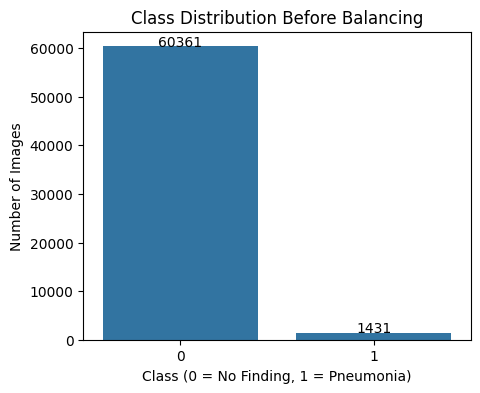

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count classes BEFORE balancing
class_counts_before = data_binary["Pneumonia"].value_counts()

plt.figure(figsize=(5,4))
sns.barplot(x=class_counts_before.index, y=class_counts_before.values)

plt.title("Class Distribution Before Balancing")
plt.xlabel("Class (0 = No Finding, 1 = Pneumonia)")
plt.ylabel("Number of Images")

for i, v in enumerate(class_counts_before.values):
    plt.text(i, v + 50, str(v), ha='center')

plt.show()

In [8]:
image_folder = base_folder
image_folders = [f for f in os.listdir(image_folder) if f.startswith("images_")]

print("Image folders found:", len(image_folders))
print(image_folders[:5])

Image folders found: 12
['images_001', 'images_002', 'images_003', 'images_004', 'images_005']


In [9]:
def find_image_path(image_name):
    for folder in image_folders:
        path = os.path.join(image_folder, folder, "images", image_name)
        if os.path.exists(path):
            return path
    return None

data_binary["path"] = data_binary["Image Index"].apply(find_image_path)
data_binary = data_binary.dropna(subset=["path"]).reset_index(drop=True)

print("Counts after path check:")
print(data_binary["Pneumonia"].value_counts())

Counts after path check:
Pneumonia
0    60360
1     1431
Name: count, dtype: int64


In [10]:
pneumonia_data = data_binary[data_binary["Pneumonia"] == 1].copy()
nofinding_data = data_binary[data_binary["Pneumonia"] == 0].copy()

n_samples = len(pneumonia_data)

pneumonia_sampled = pneumonia_data.sample(n=n_samples, random_state=42)
nofinding_sampled = nofinding_data.sample(n=n_samples, random_state=42)

data_balanced = pd.concat([pneumonia_sampled, nofinding_sampled], axis=0)
data_balanced = data_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("Balanced dataset counts:")
print(data_balanced["Pneumonia"].value_counts())
print("Total samples:", len(data_balanced))

Balanced dataset counts:
Pneumonia
0    1431
1    1431
Name: count, dtype: int64
Total samples: 2862


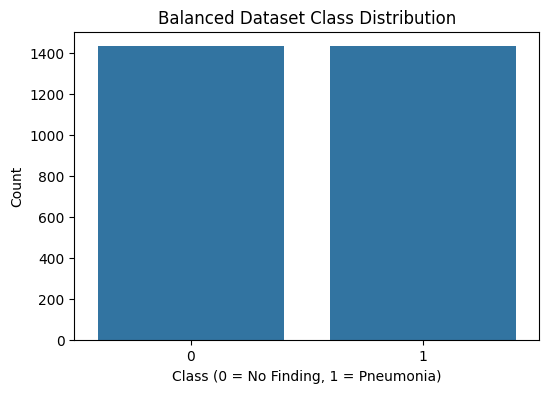

In [11]:
plt.figure(figsize=(6, 4))
sns.countplot(x=data_balanced["Pneumonia"])
plt.title("Balanced Dataset Class Distribution")
plt.xlabel("Class (0 = No Finding, 1 = Pneumonia)")
plt.ylabel("Count")
plt.show()

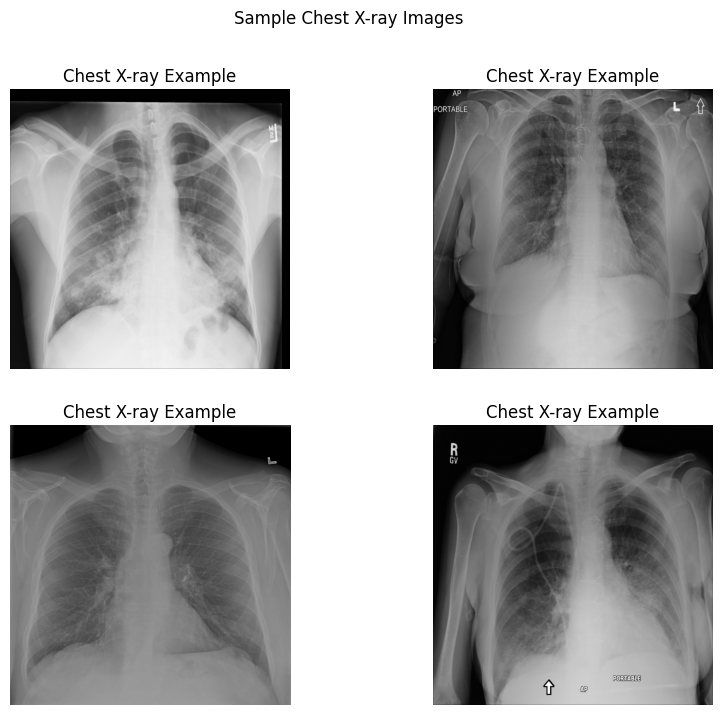

In [12]:
sample_paths = data_balanced["path"].sample(4, random_state=42)

plt.figure(figsize=(10, 8))

for i, path in enumerate(sample_paths):
    img = Image.open(path)
    plt.subplot(2, 2, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title("Chest X-ray Example")
    plt.axis("off")

plt.suptitle("Sample Chest X-ray Images")
plt.show()

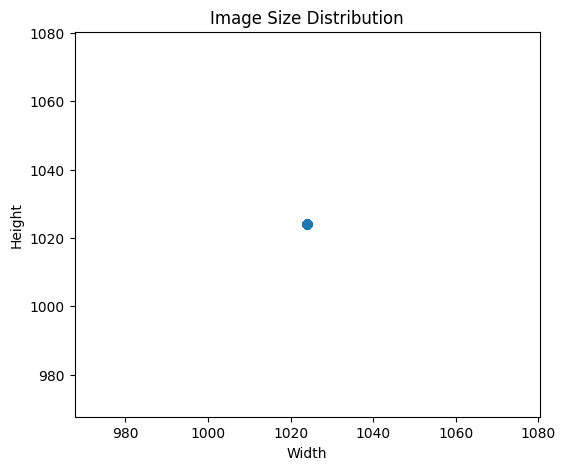

In [13]:
sizes = []

for path in data_balanced["path"].sample(min(200, len(data_balanced)), random_state=42):
    img = Image.open(path)
    sizes.append(img.size)

widths = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

plt.figure(figsize=(6, 5))
plt.scatter(widths, heights, alpha=0.6)
plt.title("Image Size Distribution")
plt.xlabel("Width")
plt.ylabel("Height")
plt.show()

In [14]:
# Split dataset into train, validation and test sets

train_data, temp_data = train_test_split(
    data_balanced,
    test_size=0.3,
    stratify=data_balanced["Pneumonia"],
    random_state=42
)

val_data, test_data = train_test_split(
    temp_data,
    test_size=0.5,
    stratify=temp_data["Pneumonia"],
    random_state=42
)

print("Train size:", len(train_data))
print("Validation size:", len(val_data))
print("Test size:", len(test_data))

print("\nTrain counts:")
print(train_data["Pneumonia"].value_counts())

print("\nValidation counts:")
print(val_data["Pneumonia"].value_counts())

print("\nTest counts:")
print(test_data["Pneumonia"].value_counts())

Train size: 2003
Validation size: 429
Test size: 430

Train counts:
Pneumonia
1    1002
0    1001
Name: count, dtype: int64

Validation counts:
Pneumonia
0    215
1    214
Name: count, dtype: int64

Test counts:
Pneumonia
0    215
1    215
Name: count, dtype: int64


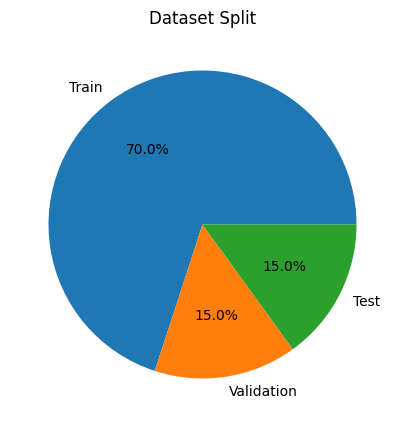

In [15]:
labels = ["Train", "Validation", "Test"]
sizes = [len(train_data), len(val_data), len(test_data)]

plt.figure(figsize=(5, 5))
plt.pie(sizes, labels=labels, autopct="%1.1f%%")
plt.title("Dataset Split")
plt.show()

In [16]:
image_size = 224
batch_size = 32

train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(8),
    transforms.ColorJitter(brightness=0.08, contrast=0.08),
    transforms.RandomAffine(
        degrees=0,
        translate=(0.03, 0.03),
        scale=(0.95, 1.05)
    ),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [17]:
# Create a custom PyTorch dataset class

class ChestXrayDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        image_path = self.dataframe.loc[index, "path"]
        label = self.dataframe.loc[index, "Pneumonia"]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [18]:
# Create training, validation and test datasets

train_dataset = ChestXrayDataset(train_data, transform=train_transform)
val_dataset = ChestXrayDataset(val_data, transform=test_transform)
test_dataset = ChestXrayDataset(test_data, transform=test_transform)

print("Train dataset size:", len(train_dataset))
print("Validation dataset size:", len(val_dataset))
print("Test dataset size:", len(test_dataset))

Train dataset size: 2003
Validation dataset size: 429
Test dataset size: 430


In [19]:
# Create dataloaders for batching

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("DataLoaders created successfully")

DataLoaders created successfully


In [20]:
def build_resnet18():
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

    # Freeze all layers first
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze last two blocks for better feature learning
    for param in model.layer3.parameters():
        param.requires_grad = True

    for param in model.layer4.parameters():
        param.requires_grad = True

    # Replace final classifier
    model.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(model.fc.in_features, 2)
    )

    return model

In [21]:
def build_densenet121():
    model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

    # Freeze all layers
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze last block (important)
    for param in model.features.denseblock4.parameters():
        param.requires_grad = True

    for param in model.features.norm5.parameters():
        param.requires_grad = True

    # Replace classifier
    model.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(model.classifier.in_features, 2)
    )

    return model

In [22]:
def train_model(model, model_name, epochs=12, learning_rate=0.0002):

    model = model.to(device)

    loss_function = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=learning_rate,
        weight_decay=1e-4
    )

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=0.5,
        patience=2
    )

    train_accuracy_history = []
    val_accuracy_history = []
    train_loss_history = []
    val_loss_history = []

    best_val_loss = float("inf")
    best_model_state = None

    for epoch in range(epochs):

        model.train()
        train_correct = 0
        train_total = 0
        train_loss_sum = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = loss_function(outputs, labels)

            loss.backward()
            optimizer.step()

            predictions = outputs.argmax(1)

            train_correct += (predictions == labels).sum().item()
            train_total += labels.size(0)
            train_loss_sum += loss.item() * labels.size(0)

        train_accuracy = train_correct / train_total
        train_loss = train_loss_sum / train_total

        model.eval()
        val_correct = 0
        val_total = 0
        val_loss_sum = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                labels = labels.to(device)

                outputs = model(images)
                loss = loss_function(outputs, labels)

                predictions = outputs.argmax(1)

                val_correct += (predictions == labels).sum().item()
                val_total += labels.size(0)
                val_loss_sum += loss.item() * labels.size(0)

        val_accuracy = val_correct / val_total
        val_loss = val_loss_sum / val_total

        scheduler.step(val_loss)

        train_accuracy_history.append(train_accuracy)
        val_accuracy_history.append(val_accuracy)
        train_loss_history.append(train_loss)
        val_loss_history.append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict()

        print(
            model_name,
            "| Epoch", epoch + 1,
            "| Train Acc:", round(train_accuracy, 3),
            "| Val Acc:", round(val_accuracy, 3),
            "| Train Loss:", round(train_loss, 3),
            "| Val Loss:", round(val_loss, 3)
        )

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return model, train_accuracy_history, val_accuracy_history, train_loss_history, val_loss_history

In [23]:
resnet_model, resnet_train_acc, resnet_val_acc, resnet_train_loss, resnet_val_loss = train_model(
    build_resnet18(),
    "ResNet18",
    epochs=12,
    learning_rate=0.0002
)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 185MB/s]


ResNet18 | Epoch 1 | Train Acc: 0.646 | Val Acc: 0.713 | Train Loss: 0.685 | Val Loss: 0.577
ResNet18 | Epoch 2 | Train Acc: 0.706 | Val Acc: 0.711 | Train Loss: 0.601 | Val Loss: 0.627
ResNet18 | Epoch 3 | Train Acc: 0.735 | Val Acc: 0.76 | Train Loss: 0.557 | Val Loss: 0.556
ResNet18 | Epoch 4 | Train Acc: 0.747 | Val Acc: 0.739 | Train Loss: 0.536 | Val Loss: 0.58
ResNet18 | Epoch 5 | Train Acc: 0.759 | Val Acc: 0.725 | Train Loss: 0.507 | Val Loss: 0.633
ResNet18 | Epoch 6 | Train Acc: 0.791 | Val Acc: 0.669 | Train Loss: 0.463 | Val Loss: 0.639
ResNet18 | Epoch 7 | Train Acc: 0.827 | Val Acc: 0.709 | Train Loss: 0.402 | Val Loss: 0.631
ResNet18 | Epoch 8 | Train Acc: 0.851 | Val Acc: 0.746 | Train Loss: 0.34 | Val Loss: 0.761
ResNet18 | Epoch 9 | Train Acc: 0.86 | Val Acc: 0.727 | Train Loss: 0.32 | Val Loss: 0.756
ResNet18 | Epoch 10 | Train Acc: 0.893 | Val Acc: 0.716 | Train Loss: 0.258 | Val Loss: 0.771
ResNet18 | Epoch 11 | Train Acc: 0.914 | Val Acc: 0.718 | Train Loss: 0.22

In [24]:
densenet_model, densenet_train_acc, densenet_val_acc, densenet_train_loss, densenet_val_loss = train_model(
    build_densenet121(),
    "DenseNet121",
    epochs=12,
    learning_rate=0.0002
)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 164MB/s]


DenseNet121 | Epoch 1 | Train Acc: 0.655 | Val Acc: 0.72 | Train Loss: 0.645 | Val Loss: 0.57
DenseNet121 | Epoch 2 | Train Acc: 0.71 | Val Acc: 0.725 | Train Loss: 0.581 | Val Loss: 0.558
DenseNet121 | Epoch 3 | Train Acc: 0.728 | Val Acc: 0.727 | Train Loss: 0.548 | Val Loss: 0.563
DenseNet121 | Epoch 4 | Train Acc: 0.743 | Val Acc: 0.711 | Train Loss: 0.531 | Val Loss: 0.569
DenseNet121 | Epoch 5 | Train Acc: 0.759 | Val Acc: 0.706 | Train Loss: 0.515 | Val Loss: 0.59
DenseNet121 | Epoch 6 | Train Acc: 0.773 | Val Acc: 0.725 | Train Loss: 0.477 | Val Loss: 0.577
DenseNet121 | Epoch 7 | Train Acc: 0.781 | Val Acc: 0.732 | Train Loss: 0.461 | Val Loss: 0.581
DenseNet121 | Epoch 8 | Train Acc: 0.795 | Val Acc: 0.72 | Train Loss: 0.442 | Val Loss: 0.6
DenseNet121 | Epoch 9 | Train Acc: 0.809 | Val Acc: 0.713 | Train Loss: 0.405 | Val Loss: 0.593
DenseNet121 | Epoch 10 | Train Acc: 0.818 | Val Acc: 0.72 | Train Loss: 0.398 | Val Loss: 0.63
DenseNet121 | Epoch 11 | Train Acc: 0.824 | Val 

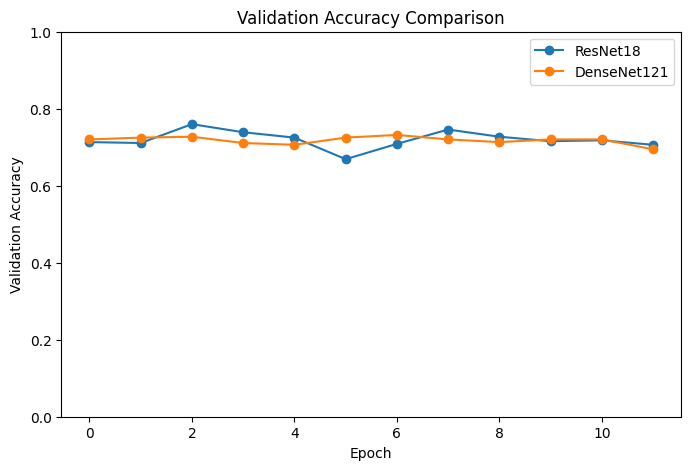

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(resnet_val_acc, marker="o", label="ResNet18")
plt.plot(densenet_val_acc, marker="o", label="DenseNet121")

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.ylim(0,1)
plt.legend()
plt.show()

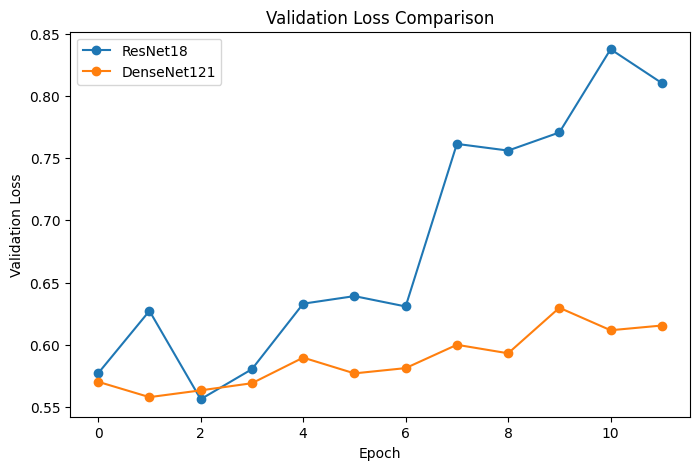

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(resnet_val_loss, marker="o", label="ResNet18")
plt.plot(densenet_val_loss, marker="o", label="DenseNet121")
plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.legend()
plt.show()

In [27]:
def evaluate_model(model, model_name):

    model = model.to(device)
    model.eval()

    true_labels = []
    predicted_labels = []
    predicted_probabilities = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)

            outputs = model(images)

            probs = torch.softmax(outputs, dim=1)[:, 1].cpu().numpy()
            preds = outputs.argmax(1).cpu().numpy()

            true_labels.extend(labels.numpy())
            predicted_labels.extend(preds)
            predicted_probabilities.extend(probs)

    accuracy = (np.array(true_labels) == np.array(predicted_labels)).mean()
    auc_score = roc_auc_score(true_labels, predicted_probabilities)

    print("\n" + "=" * 50)
    print(model_name)
    print("=" * 50)
    print(classification_report(true_labels, predicted_labels, zero_division=0))
    print("Confusion Matrix:")
    print(confusion_matrix(true_labels, predicted_labels))
    print("Accuracy:", round(accuracy, 3))
    print("ROC-AUC:", round(auc_score, 3))

    return accuracy, auc_score, true_labels, predicted_labels, predicted_probabilities

In [28]:
resnet_accuracy, resnet_auc, resnet_true, resnet_pred, resnet_prob = evaluate_model(resnet_model, "ResNet18")


ResNet18
              precision    recall  f1-score   support

           0       0.72      0.73      0.72       215
           1       0.72      0.71      0.72       215

    accuracy                           0.72       430
   macro avg       0.72      0.72      0.72       430
weighted avg       0.72      0.72      0.72       430

Confusion Matrix:
[[156  59]
 [ 62 153]]
Accuracy: 0.719
ROC-AUC: 0.774


In [29]:
densenet_accuracy, densenet_auc, densenet_true, densenet_pred, densenet_prob = evaluate_model(
    densenet_model,
    "DenseNet121"
)


DenseNet121
              precision    recall  f1-score   support

           0       0.68      0.76      0.71       215
           1       0.72      0.64      0.68       215

    accuracy                           0.70       430
   macro avg       0.70      0.70      0.70       430
weighted avg       0.70      0.70      0.70       430

Confusion Matrix:
[[163  52]
 [ 78 137]]
Accuracy: 0.698
ROC-AUC: 0.762


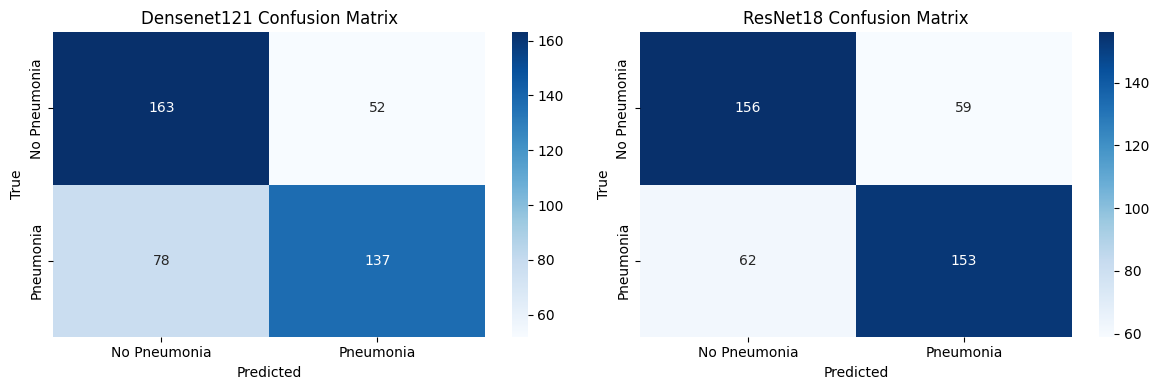

In [30]:
densenet_cm = confusion_matrix(densenet_true, densenet_pred)
resnet_cm = confusion_matrix(resnet_true, resnet_pred)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.heatmap(densenet_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Pneumonia", "Pneumonia"],
            yticklabels=["No Pneumonia", "Pneumonia"])
plt.title("Densenet121 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.subplot(1, 2, 2)
sns.heatmap(resnet_cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Pneumonia", "Pneumonia"],
            yticklabels=["No Pneumonia", "Pneumonia"])
plt.title("ResNet18 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")

plt.tight_layout()
plt.show()

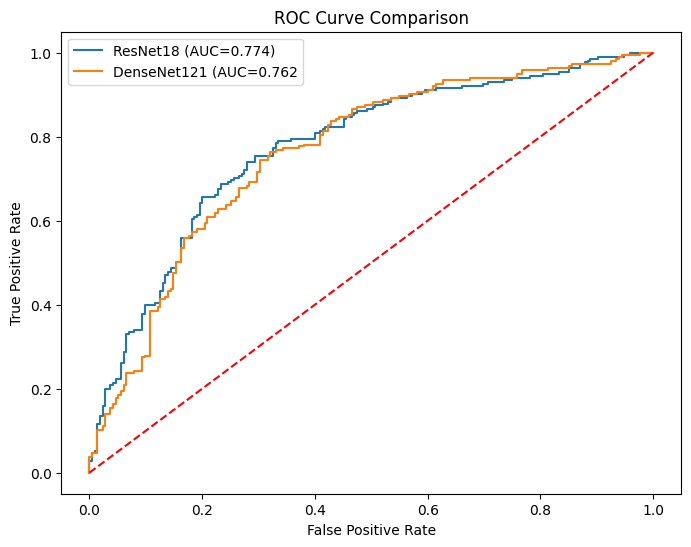

In [31]:
resnet_fpr, resnet_tpr, _ = roc_curve(resnet_true, resnet_prob)
densenet_fpr, densenet_tpr, _ = roc_curve(densenet_true, densenet_prob)

plt.figure(figsize=(8, 6))

plt.plot(resnet_fpr, resnet_tpr, label=f"ResNet18 (AUC={resnet_auc:.3f})")
plt.plot(densenet_fpr, densenet_tpr, label=f"DenseNet121 (AUC={densenet_auc:.3f}")  # ADD

plt.plot([0, 1], [0, 1], "r--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [32]:
results = pd.DataFrame({
    "Model": ["ResNet18" ,"DenseNet121"],
    "Accuracy": [resnet_accuracy, densenet_accuracy],
    "ROC_AUC": [resnet_auc, densenet_auc]
})

results

,Model,Accuracy,ROC_AUC
0,ResNet18,0.718605,0.774473
1,DenseNet121,0.697674,0.762250


In [33]:
gradcam_model = resnet_model.to(device)
gradcam_model.eval()

for param in gradcam_model.parameters():
    param.requires_grad = True

feature_maps = None
gradients = None

def forward_hook(module, input, output):
    global feature_maps
    global gradients

    feature_maps = output

    def save_gradients(grad):
        global gradients
        gradients = grad

    output.register_hook(save_gradients)

target_layer = gradcam_model.layer4[1].conv2
forward_handle = target_layer.register_forward_hook(forward_hook)

print("Grad-CAM setup complete")

Grad-CAM setup complete


In [34]:
def unnormalize_image(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).to(tensor.device)
    std = torch.tensor([0.229, 0.224, 0.225]).to(tensor.device)

    tensor = tensor.clone()
    tensor = tensor * std[:, None, None] + mean[:, None, None]

    return tensor.clamp(0, 1)

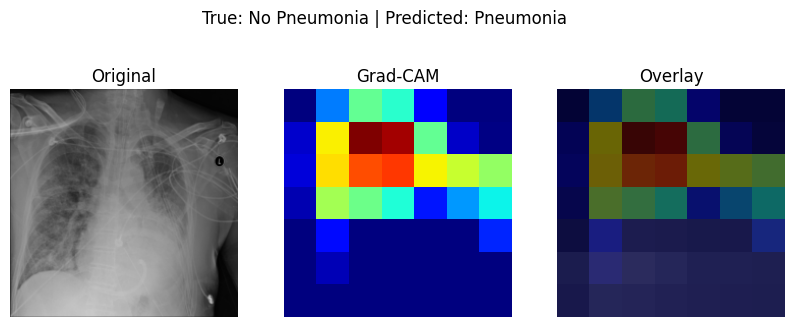

In [35]:
class_names = {0: "No Pneumonia", 1: "Pneumonia"}

image, label = test_dataset[0]
input_image = image.unsqueeze(0).to(device)

feature_maps = None
gradients = None

output = gradcam_model(input_image)
predicted_class = output.argmax(dim=1).item()

gradcam_model.zero_grad()
output[:, predicted_class].backward()

pooled_gradients = gradients.mean(dim=[0, 2, 3])
feature_maps_detached = feature_maps.detach().squeeze(0).clone()

for i in range(feature_maps_detached.shape[0]):
    feature_maps_detached[i] *= pooled_gradients[i]

cam = feature_maps_detached.mean(dim=0)
cam = torch.relu(cam)
cam = cam / (cam.max() + 1e-8)
cam = cam.cpu().numpy()

display_image = unnormalize_image(image).permute(1, 2, 0).numpy()

plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(display_image)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(cam, cmap="jet")
plt.title("Grad-CAM")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(display_image)
plt.imshow(cam, cmap="jet", alpha=0.4)
plt.title("Overlay")
plt.axis("off")

plt.suptitle(f"True: {class_names[label]} | Predicted: {class_names[predicted_class]}")
plt.show()

In [36]:
torch.save(densenet_model.state_dict(), "/content/drive/MyDrive/densenet121_model.pth")
torch.save(resnet_model.state_dict(), "/content/drive/MyDrive/resnet18_model.pth")

print("Models saved successfully")

Models saved successfully
